In [24]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np
import cv2
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
from pathlib import Path
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [25]:
# === CONFIG ===
from pathlib import Path

# Safe for notebooks: use current working directory
ROOT_DIR = Path.cwd() 
DATA_DIR = ROOT_DIR / "data" / "filtered"
MODEL_WEIGHTS = Path("/Users/mariamhusain/Desktop/resnet18_weights.pth")

# Load image paths
healthy_imgs = list((DATA_DIR / "healthy_eye").glob("*.jpg"))
infected_imgs = list((DATA_DIR / "infected_eye").glob("*.jpg"))

image_paths = healthy_imgs[:10] + infected_imgs[:10]
LABELS = {0: "Healthy", 1: "Infected"}

In [26]:
# === Load model and weights ===
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location='cpu'))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
# === Preprocess image ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [28]:
# === Initialize Grad-CAM++ ===
from pytorch_grad_cam.utils.image import preprocess_image

target_layers = [model.layer4[-1]]  # Use the last layer before classification
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

Text(0.5, 0.98, 'Grad-CAM++ Visualizations (10 Healthy + 10 Infected)')

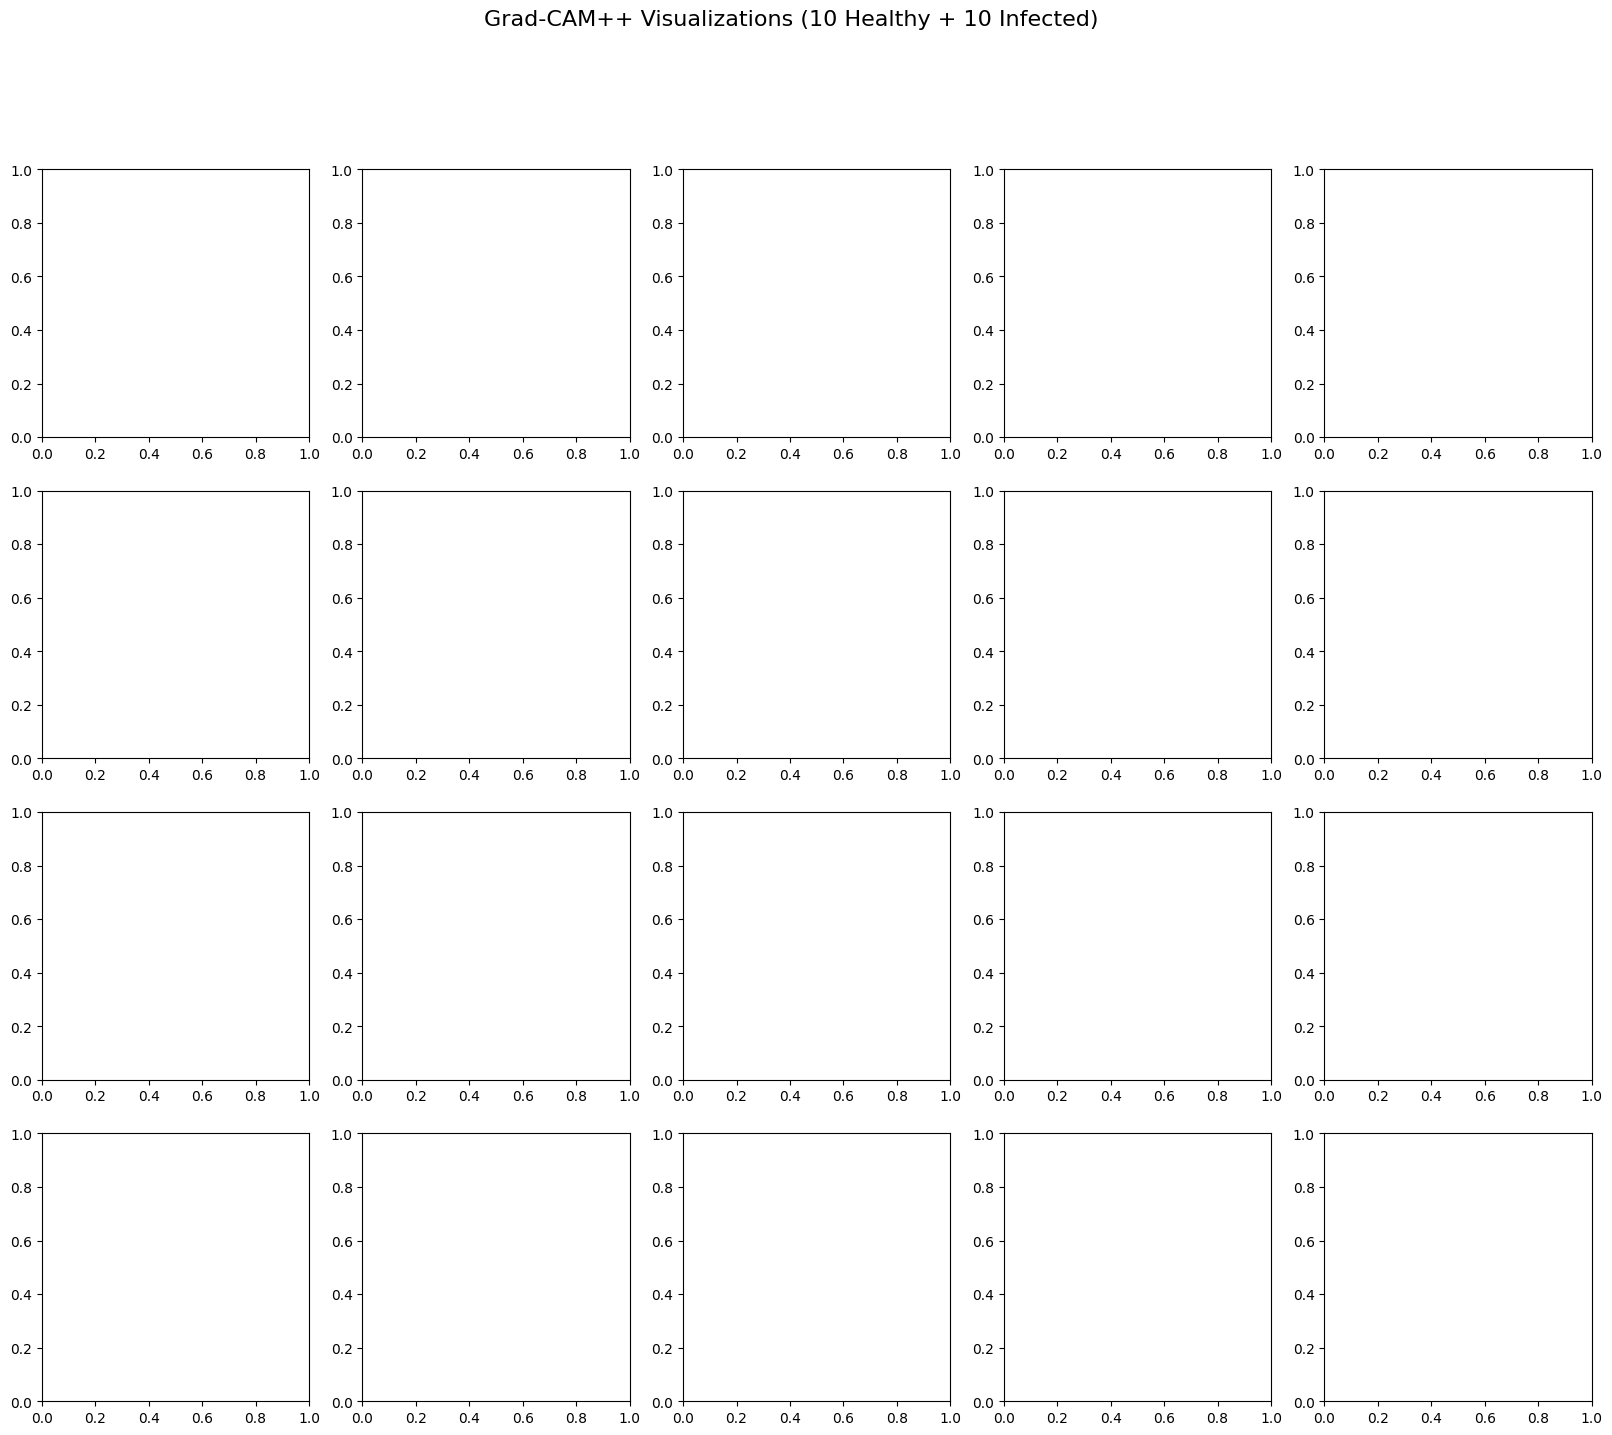

In [29]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
plt.suptitle("Grad-CAM++ Visualizations (10 Healthy + 10 Infected)", fontsize=16)

In [30]:
for idx, img_path in enumerate(image_paths):
    img_pil = Image.open(img_path).convert("RGB")
    img_np = np.array(img_pil.resize((224, 224))) / 255.0
    input_tensor = transform(img_pil).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output).item()
        pred_label = 1 if prob > 0.5 else 0

    target = [BinaryClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    ax = axes[idx // 5, idx % 5]
    ax.imshow(cam_image)
    ax.axis('off')
    ax.set_title(f"{LABELS[pred_label]} ({prob * 100:.1f}%)", fontsize=10)

In [31]:
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

<Figure size 640x480 with 0 Axes>